In [1]:
import re
import nltk
import joblib
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collection.Collection import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\SRK\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\SRK\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\SRK\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\SRK\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\SRK\AppData\Roaming\nltk_data...
[nltk_data]

True

In [3]:
df = pd.read_csv(r'IMDB Dataset.csv')

# Preprocess helper functions

In [4]:
def remove_duplicates_to_lowercase(df, text_col, verbose=False):
    before = len(df)
    df = df.drop_duplicates().copy()
    after = len(df)

    if verbose:
        print(f"Removed {before - after} duplicate rows")

    df[text_col] = df[text_col].astype(str).str.lower()
    return df

def preprocess(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def word_counts(text):
    return len(text.split())

def count_stopwords(text,stop_words):
    # stop_words = set(stopwords.words('english'))
    return sum(1 for word in text.split() if word in stop_words)

def count_punctuation_chars(text):
    punctuation = '.,!?;:"\'()[]{}-'
    return sum(1 for char in text if char in punctuation)

def remove_special_characters(text):
    """
    Keeps only letters, numbers, spaces, and basic punctuation (! ? . ,)
    """
    text = str(text)
    return re.sub(r'[^A-Za-z0-9\s!?.,]', '', text)

def remove_stopwords(text,custom_stop_words):
    # stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    text = ' '.join([word for word in text.split() if word not in custom_stop_words])
    return text

def lemmantize_text(text,lemmantizer):
    text = ' '.join([lemmantizer.lemmatize(word) for word in text.split()])
    return text

# EDA Process

In [5]:
def eda_processes(df,text,target,word_count,no_of_stopwords,clean_text):

    def basic_plots():

        sns.countplot(x=target, data=df)
        plt.show()

        sns.kdeplot(df[df[target] == 1][word_count], label='Positive', fill=True)
        sns.kdeplot(df[df[target] == 0][word_count], label='Negative', fill=True)
        plt.legend()
        plt.show()

        sns.boxplot(data=df,x=target,y=word_count)
        plt.show()

        sns.kdeplot(df[df[target] == 1][no_of_stopwords], label='Positive', fill=True)
        sns.kdeplot(df[df[target] == 0][no_of_stopwords], label='Negative', fill=True)
        plt.legend()
        plt.show()

    basic_plots()

    def get_top_ngrams(corpus, n=None):
        vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
        return words_freq[:n]

    top_25_bigrams = get_top_ngrams(df[clean_text], 25)
    top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
    plt.title('Top 25 Most Common Bigrams')
    plt.xlabel('Count')
    plt.ylabel('Bigram')
    plt.show()

    # --- IGNORE ---
    # def generate_wordcloud():
    #     wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    #     plt.figure(figsize=(10, 5))
    #     plt.imshow(wordcloud, interpolation='bilinear')
    #     plt.axis("off")
    #     plt.show()
    
    # generate_wordcloud()
    # --- IGNORE ---
    def plot_top_n_words(df, n=20):
        """Plot the top N most frequent words in the dataset."""
        # Flatten all words in the content column
        words = ' '.join(df[clean_text]).split()

        counter = Counter(words)
        most_common_words = counter.most_common(n)

        # Split the words and their counts for plotting
        words, counts = zip(*most_common_words)

        # Plot the top N words
        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(counts), y=list(words))
        plt.title(f'Top {n} Most Frequent Words')
        plt.xlabel('Frequency')
        plt.ylabel('Words')
        plt.show()

    # Example usage
    plot_top_n_words(df)

# Model Building

In [ ]:
def model_training(df,text=None,vectorizer=None,clean_text=None,target=None,word_count=None,no_of_stopwords=None):
    y = df[target]
    X = df[[clean_text, target,word_count, no_of_stopwords]]
    X = vectorizer.fit_transformation

In [ ]:
def main():

    CSV_FILE_NAME = r'IMDB Dataset.csv'
    OUTPUT_CLEANED_CSV = "CLEANED " + r'IMDB Dataset.csv'
    STOP_WORDS = set(stopwords.words('english'))
    CUSTOM_STOP_WORDS = STOP_WORDS - {'not', 'but', 'however', 'no', 'yet'}
    LEMMANTIZER = WordNetLemmatizer()
    VECTORIZER = CountVectorizer(max_features=10000)

    text = 'review'
    target = 'sentiment'
    no_of_stopwords = 'no.of_stopwords'
    word_count = 'word_count'
    char_count = 'char_count'
    punctuation_chars = 'num_punctuation_chars'
    clean_text = 'review_clean'
    temp_col = '_processed'

    df = pd.read_csv(CSV_FILE_NAME)
    df = remove_duplicates_to_lowercase(df, text, verbose=True)
    df[temp_col] = df[text].astype(str).apply(preprocess)
    df[no_of_stopwords] = df[temp_col].apply(lambda x: count_stopwords(x, stop_words=CUSTOM_STOP_WORDS))
    df[word_count] = df[temp_col].apply(word_counts)
    df[char_count] = df[temp_col].apply(len)
    df[punctuation_chars] = df[temp_col].apply(count_punctuation_chars)
    df[clean_text] = df[temp_col].apply(remove_special_characters)
    df[clean_text] = df[clean_text].apply(lambda x: remove_stopwords(x, custom_stop_words=CUSTOM_STOP_WORDS))
    df[clean_text] = df[clean_text].apply(lambda x: lemmantize_text(x, lemmantizer=LEMMANTIZER))
    df.drop(columns=[temp_col],inplace=True)

    le = LabelEncoder()
    df[target] = le.fit_transform(df[target])
    df.to_csv(OUTPUT_CLEANED_CSV, index=False)

    eda_processes(df,text=text,clean_text=clean_text,target=target,word_count=word_count,no_of_stopwords=no_of_stopwords)

    preprocessed_csv = pd.read_csv(OUTPUT_CLEANED_CSV)
    model_training(preprocessed_csv,vectorizer=VECTORIZER,text=text,clean_text=clean_text,target=target,word_count=word_count,no_of_stopwords=no_of_stopwords)

    user_text = "This movie was fantastic! I \n <br>   really loved it. and https://chatgpt.com/c/6968b1de-2f14-832a-bcc0-f048bbdad653"
    processed_text = preprocess(user_text)
    stopwords_count_user_text = count_stopwords(processed_text, stop_words=CUSTOM_STOP_WORDS)
    word_count_user_text = word_counts(processed_text)
    punctuation_count_user_text = count_punctuation_chars(processed_text)
    remove_special_characters_user_text = remove_special_characters(processed_text)
    char_count_user_text = len(remove_special_characters_user_text)
    remove_stopwods_user_text = remove_stopwords(remove_special_characters_user_text,custom_stop_words=CUSTOM_STOP_WORDS)
    lemmantize_user_text = lemmantize_text(remove_stopwods_user_text, lemmantizer=LEMMANTIZER)

    user_raw_data = {
        text: user_text,
        clean_text: lemmantize_user_text,
        no_of_stopwords: stopwords_count_user_text,
        word_count: word_count_user_text,
        char_count: char_count_user_text,
        punctuation_chars: punctuation_count_user_text
    }
    user_df = pd.DataFrame(user_raw_data,index=[0])

    print(processed_text)
    print("Dataset Head \n",df.head())
    print("User Text DataFrame \n",user_df)

Removed 418 duplicate rows


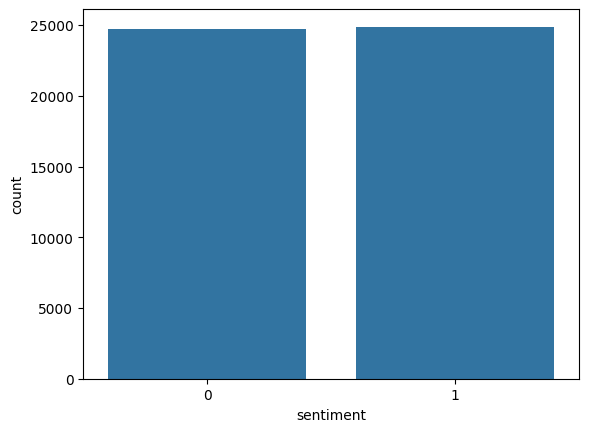

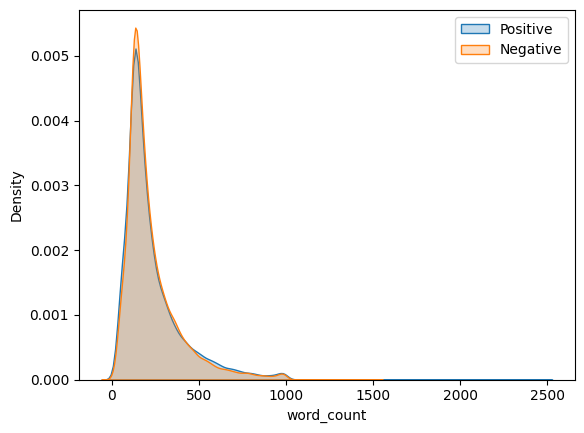

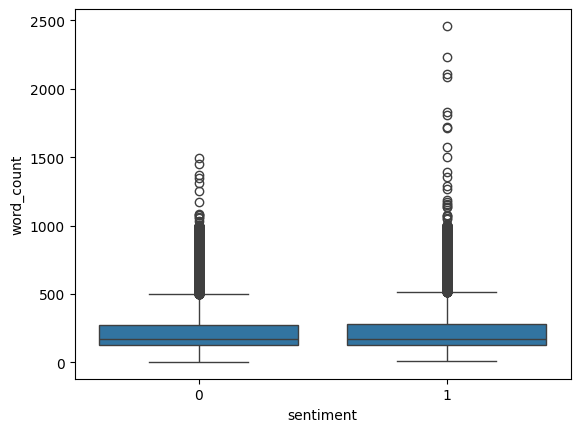

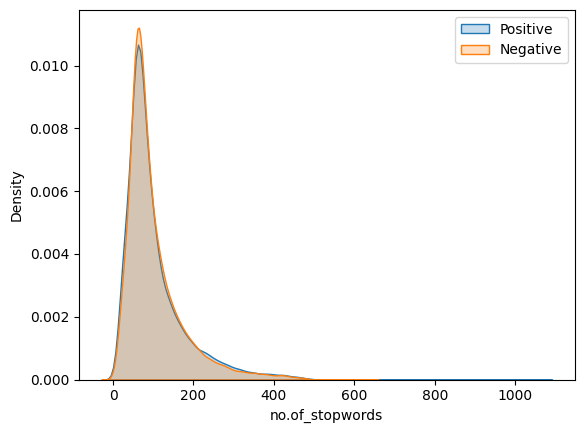

C:\Users\SRK\AppData\Local\Temp\ipykernel_28232\3817987586.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


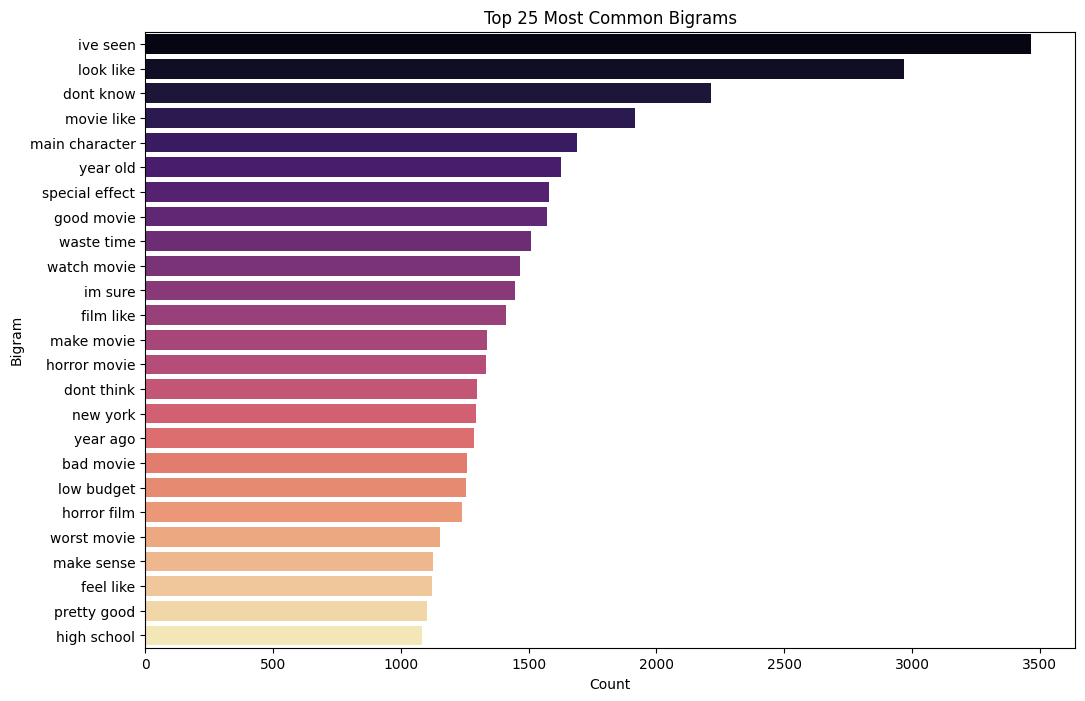

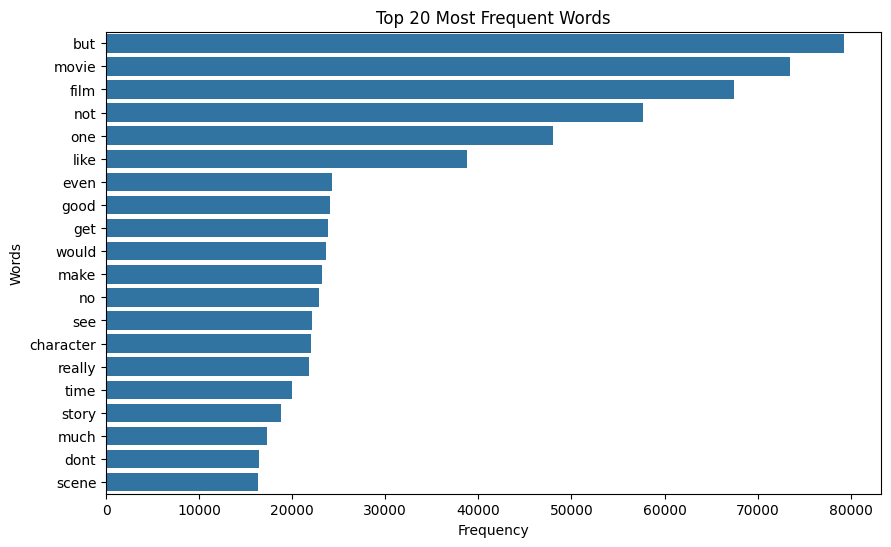

this movie was fantastic! i really loved it. and
Dataset Head 
                                               review  sentiment  \
0  one of the other reviewers has mentioned that ...          1   
1  a wonderful little production. <br /><br />the...          1   
2  i thought this was a wonderful way to spend ti...          1   
3  basically there's a family where a little boy ...          0   
4  petter mattei's "love in the time of money" is...          1   

   no.of_stopwords  word_count  char_count  num_punctuation_chars  \
0              130         304        1728                     60   
1               65         156         962                     26   
2               75         164         904                     28   
3               63         135         715                     21   
4               97         225        1272                     32   

                                        review_clean  
0  one reviewer mentioned watching 1 oz episode y...  
1  wonde

In [7]:
main()

def setup_logger():
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.DEBUG)

    if not logger.handlers:
        handler = logging.FileHandler("app.log")
        handler.setLevel(logging.DEBUG)

        formatter = logging.Formatter(
            "%(asctime)s - %(levelname)s - %(message)s"
        )

        handler.setFormatter(formatter)
        logger.addHandler(handler)

    return logger

logger = setup_logger()
logger.info("Application started")
logger.debug("this is a debug msg")
